# 成长股策略回测

In [1]:
import sys, os
_ROOT = os.getcwd()
for _ in range(4):
    if os.path.exists(os.path.join(_ROOT, "scripts", "graham_dodd_lib.py")):
        break
    _ROOT = os.path.dirname(_ROOT)
os.chdir(_ROOT)

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

INITIAL_CAPITAL = 1_000_000.0
POSITION_SIZE = 100_000.0
MAX_POSITIONS = 10
MAX_PER_STOCK = 2
STOP_LOSS = -0.20
TAKE_PROFIT = 1.00
START_DATE = "2020-01-01"
END_DATE = "2026-08-31"
DATA_DIR = os.path.join(_ROOT, "data")
print("参数设置完成")

参数设置完成


## 1. 加载数据

In [2]:
def load_all_market_data(start_date="2020-01-01", end_date="2026-08-31"):
    meta_path = os.path.join(DATA_DIR, "meta", "graham_universe.csv")
    universe = pd.read_csv(meta_path, dtype={"code": str})
    codes = universe["code"].tolist()
    market_data = {}
    for code in codes:
        path = os.path.join(DATA_DIR, f"{code}_qfq.csv")
        if not os.path.exists(path):
            continue
        try:
            df = pd.read_csv(path, index_col="date", parse_dates=True)
            if df.empty or len(df) < 60:
                continue
            df = df[(df.index >= start_date) & (df.index <= end_date)]
            market_data[code] = df
        except Exception:
            continue
    print(f"加载 {len(market_data)} 只股票")
    return market_data

ALL_MARKET_DATA = load_all_market_data()

加载 4265 只股票


In [3]:
def precompute_indicators(market_data):
    indicators = {}
    for code, df in market_data.items():
        if len(df) < 60:
            continue
        df_ind = pd.DataFrame(index=df.index)
        df_ind["year_return"] = df["close"].pct_change(252)
        window = min(252, len(df))
        df_ind["price_rank"] = df["close"].rolling(window).apply(
            lambda x: (x.iloc[-1] > x).sum() / len(x) if len(x) > 0 else 0.5
        )
        indicators[code] = df_ind
    return indicators

ALL_INDICATORS = precompute_indicators(ALL_MARKET_DATA)
print(f"预计算完成: {len(ALL_INDICATORS)} 只")

预计算完成: 4265 只


## 2. 选股逻辑

In [4]:
def screen_stocks(as_of_date, market_data, indicators):
    as_of = pd.Timestamp(as_of_date)
    candidates = []
    for code, df in market_data.items():
        df_up_to = df[df.index <= as_of]
        if len(df_up_to) < 60:
            continue
        ind = indicators.get(code)
        if ind is None:
            continue
        ind_up_to = ind[ind.index <= as_of]
        if ind_up_to.empty:
            continue
        year_return = ind_up_to["year_return"].iloc[-1]
        if pd.isna(year_return) or year_return < 0.1:
            continue
        price_rank = ind_up_to["price_rank"].iloc[-1]
        if pd.isna(price_rank) or price_rank > 0.50:
            continue
        code_num = int(code)
        if code_num < 1000:
            continue
        candidates.append(code)
    return candidates

print("选股函数定义完成")

选股函数定义完成


## 3. 回测引擎

In [5]:
from dataclasses import dataclass
from typing import Dict, List

@dataclass
class Position:
    code: str
    buy_date: str
    buy_price: float
    shares: int
    shares_count: int = 1

@dataclass
class Trade:
    date: str
    code: str
    action: str
    price: float
    shares: int
    amount: float
    reason: str

class GrowthStockBacktest:
    def __init__(self, initial_capital: float):
        self.initial_capital = initial_capital
        self.cash = initial_capital
        self.positions: Dict[str, Position] = {}
        self.trades: List[Trade] = []
        self.equity_curve = []
    
    def get_price(self, code, date, market_data):
        df = market_data.get(code)
        if df is None:
            return 0
        if date in df.index:
            return df.loc[date, "close"]
        mask = df.index <= date
        if mask.any():
            return df.loc[mask, "close"].iloc[-1]
        return 0
    
    def check_stop_loss(self, date, market_data):
        for code in list(self.positions.keys()):
            pos = self.positions[code]
            price = self.get_price(code, date, market_data)
            if price <= 0:
                continue
            ret = (price - pos.buy_price) / pos.buy_price
            if ret <= STOP_LOSS:
                proceeds = pos.shares * price * 0.999
                self.cash += proceeds
                self.trades.append(Trade(date, code, "sell", price, pos.shares, proceeds, "stop_loss"))
                del self.positions[code]
    
    def check_take_profit(self, date, market_data):
        for code in list(self.positions.keys()):
            pos = self.positions[code]
            if pos.shares_count >= MAX_PER_STOCK:
                continue
            price = self.get_price(code, date, market_data)
            if price <= 0:
                continue
            ret = (price - pos.buy_price) / pos.buy_price
            if ret >= TAKE_PROFIT:
                add_amount = min(POSITION_SIZE, self.cash)
                add_shares = int(add_amount / price / 100) * 100
                if add_shares <= 0:
                    continue
                cost = add_shares * price * 1.0003
                if cost > self.cash:
                    continue
                total_shares = pos.shares + add_shares
                avg_price = (pos.shares * pos.buy_price + add_shares * price) / total_shares
                pos.shares = total_shares
                pos.buy_price = avg_price
                pos.shares_count += 1
                self.cash -= cost
                self.trades.append(Trade(date, code, "buy", price, add_shares, cost, "add_position"))
    
    def buy_new(self, code, date, market_data):
        if code in self.positions:
            return
        if len(self.positions) >= MAX_POSITIONS:
            return
        price = self.get_price(code, date, market_data)
        if price <= 0:
            return
        buy_amount = min(POSITION_SIZE, self.cash)
        shares = int(buy_amount / price / 100) * 100
        if shares <= 0:
            return
        cost = shares * price * 1.0003
        if cost > self.cash:
            return
        self.positions[code] = Position(code, date, price, shares)
        self.cash -= cost
        self.trades.append(Trade(date, code, "buy", price, shares, cost, "new_position"))
    
    def rebalance(self, date, candidates, market_data):
        self.check_stop_loss(date, market_data)
        self.check_take_profit(date, market_data)
        for code in candidates:
            if code not in self.positions:
                self.buy_new(code, date, market_data)
    
    def calc_nav(self, date, market_data):
        pos_value = 0
        for code, pos in self.positions.items():
            price = self.get_price(code, date, market_data)
            pos_value += pos.shares * price
        nav = self.cash + pos_value
        self.equity_curve.append({"date": date, "nav": nav})
        return nav

engine = GrowthStockBacktest(INITIAL_CAPITAL)
print("回测引擎初始化完成")

回测引擎初始化完成


## 4. 运行回测

In [6]:
def get_rebalance_dates(start="2020-01-01", end="2026-08-31"):
    dates = pd.date_range(start=start, end=end, freq="BMS")
    return [d.strftime("%Y-%m-%d") for d in dates if d.month in [1, 4, 7, 10]]

def run_backtest():
    rebalance_dates = get_rebalance_dates(START_DATE, END_DATE)
    print(f"调仓日期: {len(rebalance_dates)} 个")
    engine = GrowthStockBacktest(INITIAL_CAPITAL)
    for i, date in enumerate(rebalance_dates):
        candidates = screen_stocks(date, ALL_MARKET_DATA, ALL_INDICATORS)
        engine.rebalance(date, candidates, ALL_MARKET_DATA)
        nav = engine.calc_nav(date, ALL_MARKET_DATA)
        n_pos = len(engine.positions)
        print(f"[{i+1}/{len(rebalance_dates)}] {date}: 净值={nav:,.0f}, 持仓={n_pos}只")
    equity_df = pd.DataFrame(engine.equity_curve).set_index("date")
    return equity_df, engine

equity_df, engine = run_backtest()

调仓日期: 27 个
[1/27] 2020-01-01: 净值=1,000,000, 持仓=0只
[2/27] 2020-04-01: 净值=1,000,000, 持仓=0只
[3/27] 2020-07-01: 净值=1,000,000, 持仓=0只
[4/27] 2020-10-01: 净值=1,000,000, 持仓=0只
[5/27] 2021-01-01: 净值=1,000,000, 持仓=0只
[6/27] 2021-04-01: 净值=1,000,000, 持仓=0只
[7/27] 2021-07-01: 净值=1,000,000, 持仓=0只
[8/27] 2021-10-01: 净值=1,000,000, 持仓=0只
[9/27] 2022-01-03: 净值=1,000,000, 持仓=0只
[10/27] 2022-04-01: 净值=1,000,000, 持仓=0只
[11/27] 2022-07-01: 净值=1,000,000, 持仓=0只
[12/27] 2022-10-03: 净值=1,000,000, 持仓=0只
[13/27] 2023-01-02: 净值=1,000,000, 持仓=0只
[14/27] 2023-04-03: 净值=1,000,000, 持仓=0只
[15/27] 2023-07-03: 净值=1,000,000, 持仓=0只
[16/27] 2023-10-02: 净值=1,000,000, 持仓=0只
[17/27] 2024-01-01: 净值=999,702, 持仓=10只
[18/27] 2024-04-01: 净值=974,868, 持仓=10只
[19/27] 2024-07-01: 净值=841,132, 持仓=9只
[20/27] 2024-10-01: 净值=969,496, 持仓=9只
[21/27] 2025-01-01: 净值=1,253,442, 持仓=9只
[22/27] 2025-04-01: 净值=1,304,288, 持仓=9只
[23/27] 2025-07-01: 净值=1,258,639, 持仓=9只
[24/27] 2025-10-01: 净值=1,370,809, 持仓=9只
[25/27] 2026-01-01: 净值=1,258,948, 持仓=9只
[26/

## 5. 绩效评估

In [8]:
import matplotlib.pyplot as plt

def calc_metrics(df, engine):
    df = df.copy()
    if not pd.api.types.is_datetime64_any_dtype(df.index):
        df.index = pd.to_datetime(df.index)
    df["ret"] = df["nav"].pct_change()
    total_return = df["nav"].iloc[-1] / df["nav"].iloc[0] - 1
    years = (df.index[-1] - df.index[0]).days / 365.25
    annual_return = (1 + total_return) ** (1/years) - 1
    df["peak"] = df["nav"].cummax()
    max_dd = ((df["nav"] - df["peak"]) / df["peak"]).min()
    sharpe = df["ret"].mean() / df["ret"].std() * np.sqrt(252) if df["ret"].std() > 0 else 0
    df["year"] = df.index.year
    yearly = df.groupby("year")["nav"].apply(lambda x: x.iloc[-1]/x.iloc[0]-1)
    print("="*50)
    print("绩效指标")
    print("="*50)
    print(f"初始资金: {INITIAL_CAPITAL:,.0f} 元")
    print(f"最终净值: {df["nav"].iloc[-1]:,.0f} 元")
    print(f"总收益率: {total_return:.2%}")
    print(f"年化收益: {annual_return:.2%}")
    print(f"最大回撤: {max_dd:.2%}")
    print(f"夏普比率: {sharpe:.2f}")
    print(f"交易次数: {len(engine.trades)}")
    print("年度收益:")
    for y, r in yearly.items():
        print(f"  {y}: {r:.2%}")
    print("="*50)
    return {"annual_return": annual_return, "max_dd": max_dd, "sharpe": sharpe, "yearly": yearly}

metrics = calc_metrics(equity_df, engine)

绩效指标
初始资金: 1,000,000 元
最终净值: 1,054,810 元
总收益率: 5.48%
年化收益: 0.82%
最大回撤: -23.05%
夏普比率: 0.97
交易次数: 27
年度收益:
  2020: 0.00%
  2021: 0.00%
  2022: 0.00%
  2023: 0.00%
  2024: -3.02%
  2025: 9.36%
  2026: -16.21%


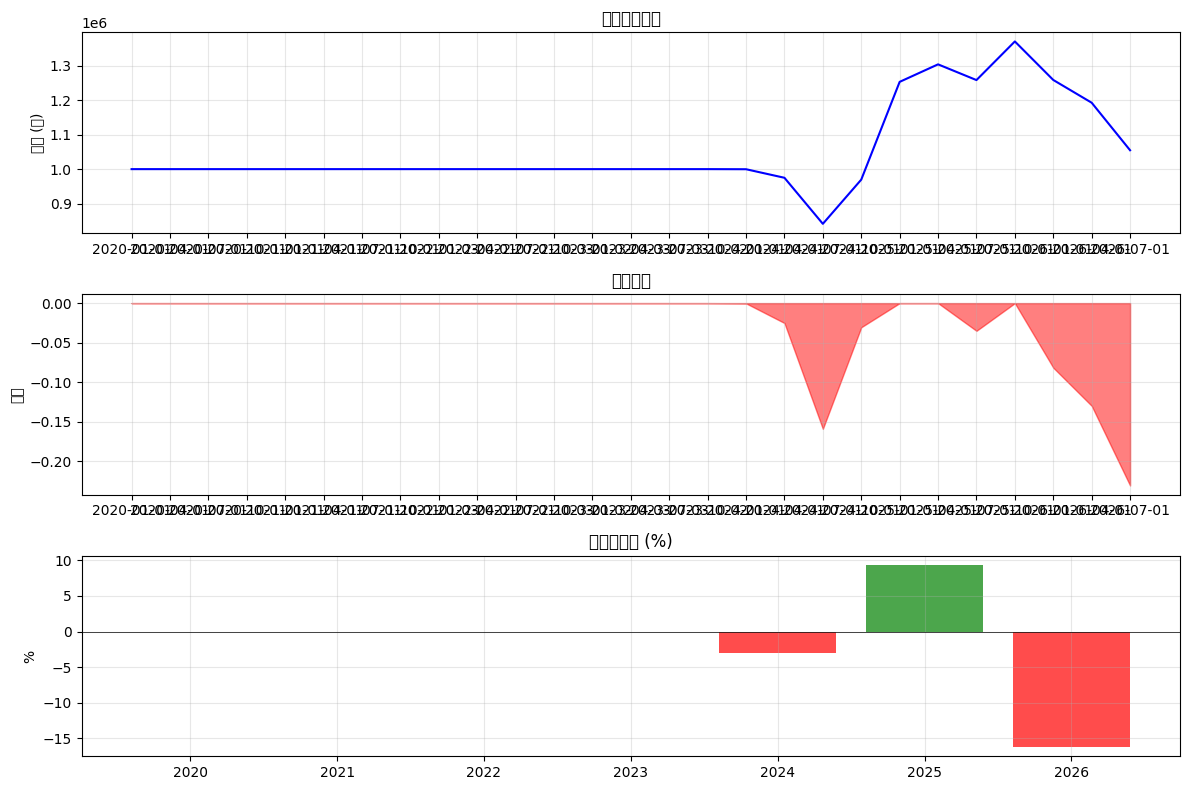

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8))
axes[0].plot(equity_df.index, equity_df["nav"], "b-", linewidth=1.5)
axes[0].set_title("策略净值曲线")
axes[0].set_ylabel("净值 (元)")
axes[0].grid(True, alpha=0.3)
equity_df["peak"] = equity_df["nav"].cummax()
equity_df["dd"] = (equity_df["nav"] - equity_df["peak"]) / equity_df["peak"]
axes[1].fill_between(equity_df.index, equity_df["dd"], 0, alpha=0.5, color="red")
axes[1].set_title("回撤曲线")
axes[1].set_ylabel("回撤")
axes[1].grid(True, alpha=0.3)
yearly = metrics["yearly"]
colors = ["green" if r > 0 else "red" for r in yearly.values]
axes[2].bar(yearly.index.astype(str), yearly.values * 100, color=colors, alpha=0.7)
axes[2].set_title("年度收益率 (%)")
axes[2].set_ylabel("%")
axes[2].grid(True, alpha=0.3)
axes[2].axhline(y=0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

In [ ]:
ww'w'w'w'w'w'w'w'w'w'w'w